<a href="https://colab.research.google.com/github/yuniecorn-dev/esaa_assignment/blob/main/%EA%B7%B8%EB%A3%B9%ED%94%84%EB%A1%9C%EC%A0%9D%ED%8A%B8_%EB%8B%A4%EB%B3%80%EB%9F%89%EB%B6%84%EC%84%9D%EC%BD%94%EB%93%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##1. 자료 정리 및 전처리
- 설문조사 문항 전체가 컬럼명으로 되어 있어 다루기 어려워 직관적인 영문 변수명으로 매핑
- 일평균 소셜 미디어 사용 시간을 텍스트형에서 숫자형 연속/순서 변수로 변환하여 분석이 가능하도록 전처리

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import statsmodels.api as sm

In [2]:
df = pd.read_csv('smmh.csv')

In [3]:
# 분석을 용이하게 하기 위한 컬럼명 영문 단순화
col_mapping = {
    '1. What is your age?': 'Age',
    '2. Gender': 'Gender',
    '8. What is the average time you spend on social media every day?': 'SM_Time',
    '9. How often do you find yourself using Social media without a specific purpose?': 'Purposeless_Use',
    '10. How often do you get distracted by Social media when you are busy doing something?': 'SM_Distraction',
    "11. Do you feel restless if you haven't used Social media in a while?": 'Restlessness',
    '12. On a scale of 1 to 5, how easily distracted are you?': 'Easily_Distracted',
    '13. On a scale of 1 to 5, how much are you bothered by worries?': 'Worries',
    '14. Do you find it difficult to concentrate on things?': 'Concentration_Difficulty',
    '15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?': 'Comparison',
    '16. Following the previous question, how do you feel about these comparisons, generally speaking?': 'Comparison_Feeling',
    '17. How often do you look to seek validation from features of social media?': 'Validation_Seeking',
    '18. How often do you feel depressed or down?': 'Depression',
    '19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?': 'Interest_Fluctuation',
    '20. On a scale of 1 to 5, how often do you face issues regarding sleep?': 'Sleep_Issues'
}
df.rename(columns=col_mapping, inplace=True)

In [4]:
# 주요 분석 변수 추출 및 결측치 제거
cols_to_use = list(col_mapping.values())
df_clean = df[cols_to_use].copy()

In [5]:
# 사용 시간(텍스트)을 순서형 수치 데이터로 변환
time_mapping = {
    'Less than an Hour': 0.5,
    'Between 1 and 2 hours': 1.5,
    'Between 2 and 3 hours': 2.5,
    'Between 3 and 4 hours': 3.5,
    'Between 4 and 5 hours': 4.5,
    'More than 5 hours': 6.0
}
df_clean['SM_Time_Num'] = df_clean['SM_Time'].map(time_mapping)
df_clean.dropna(inplace=True)

##2. EDA
상관관계 히트맵
- 우울감(Depression)은 걱정(Worries, 0.59) 및 집중력 저하(Concentration Difficulty, 0.50)와 가장 강한 양의 상관관계
- 목적 없는 소셜 미디어 사용(Purposeless Use)은 소셜미디어로 인한 주의 산만(SM Distraction, 0.58)과 높은 상관관계를 보이며, 이는 습관적인 사용이 일상생활의 집중력 저하로 이어짐을 나타냄.

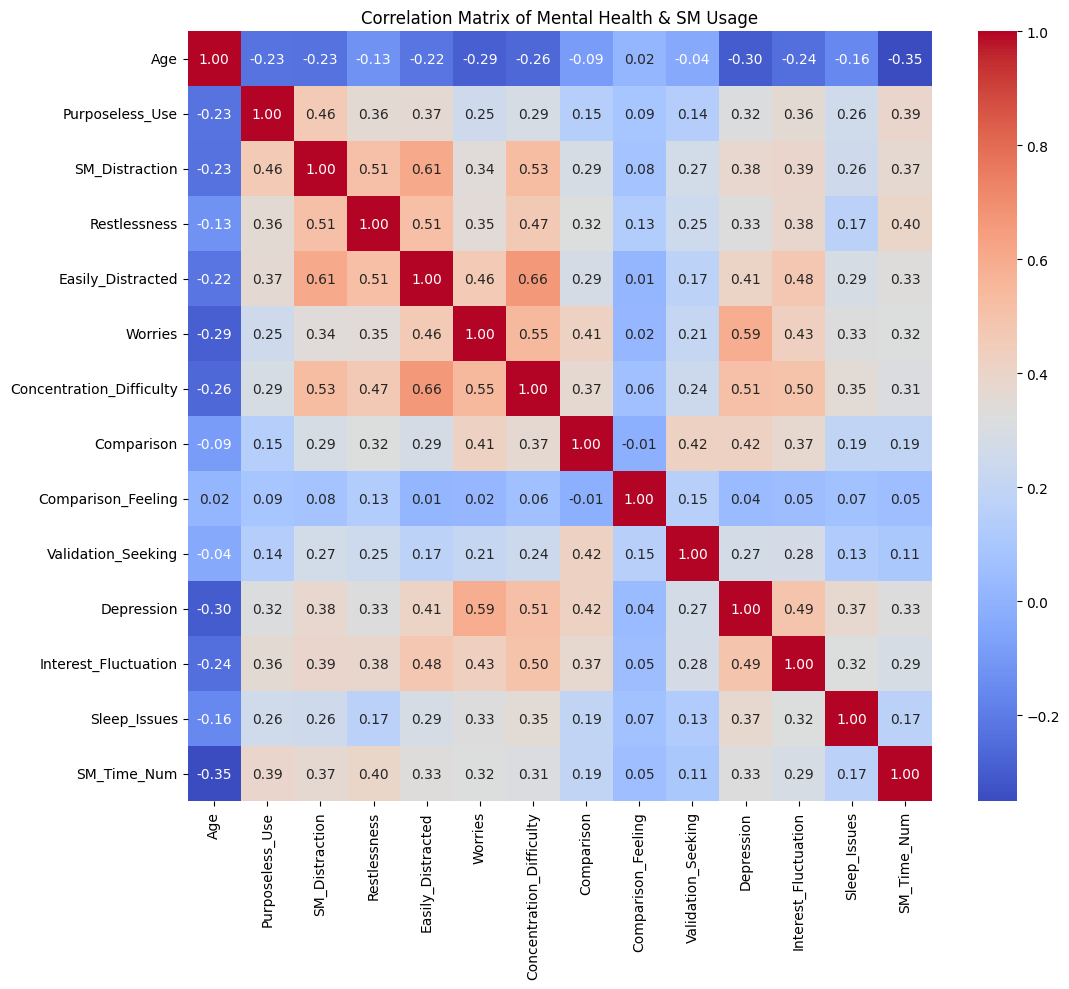

In [7]:
plt.figure(figsize=(12, 10))
corr = df_clean.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Mental Health & SM Usage')
plt.show()

##3. 다변량 분석

###① 다중 선형 회귀 분석 (우울감에 미치는 요인 분석)

소셜 미디어 사용 습관과 정신 건강 지표들이 우울감에 미치는 영향을 다변량 선형 회귀로 분석
- 모델의 설명력($R^2$): 약 45.7%
- 유의미한 변수 (P-value < 0.05)
  - 걱정(Worries, 계수: 0.362)
  - 집중력 저하(Concentration Difficulty, 계수: 0.157)
  - 타인과의 비교(Comparison, 계수: 0.127)
  - 목적 없는 사용(Purposeless Use, 계수: 0.120)
  - 수면 문제(Sleep Issues, 계수: 0.120)
- 해석: 소셜 미디어를 하면서 단순히 산만해지는 것(SM_Distraction)보다 **아무 목적 없이 앱을 켜는 습관**과 **타인과 자신을 비교하는 행위**가 우울감을 직접적으로 크게 높이는 주요 원인

In [8]:
# 우울감(Depression)을 종속변수로, 다른 행동/심리 요인을 독립변수로 설정
X_cols = ['Purposeless_Use', 'SM_Distraction', 'Restlessness', 'Easily_Distracted',
          'Worries', 'Concentration_Difficulty', 'Comparison', 'Validation_Seeking', 'Sleep_Issues']
X = df_clean[X_cols]
X = sm.add_constant(X)
y = df_clean['Depression']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             Depression   R-squared:                       0.457
Model:                            OLS   Adj. R-squared:                  0.447
Method:                 Least Squares   F-statistic:                     44.03
Date:                Sat, 16 May 2026   Prob (F-statistic):           4.22e-57
Time:                        16:21:21   Log-Likelihood:                -666.17
No. Observations:                 481   AIC:                             1352.
Df Residuals:                     471   BIC:                             1394.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

###② K-Means 군집 분석 (사용자 유형 분류)

비지도 학습 다변량 분석을 통해 비슷한 특성을 가진 응답자를 3개의 군집(Cluster)으로 분류
- Cluster 1 (건강한 사용자군)
  - 소셜 미디어 사용 시간이 가장 적음.(평균 2.6점)
  - 주의 산만, 타인과의 비교, 우울감 등 모든 수치가 가장 낮음.
- Cluster 0 (수동적 과다 사용자군)
  - 소셜 미디어 사용 시간도 길고 걱정(Worries) 수치도 높음.
  - 타인과의 비교(2.4점)나 인정 욕구(1.6점)는 낮은 편임.
  - 우울감은 중간 정도임.
- Cluster 2 (비교/인정 욕구형 과다 사용자군)
  - 소셜 미디어 사용 시간이 긺.
  - 타인과의 비교(4.0점), 인정 욕구(3.5점)가 다른 군집에 비해 압도적으로 높음.
  - 그 결과 우울감(4.0점) 또한 3개 군집 중 최고치에 달함.

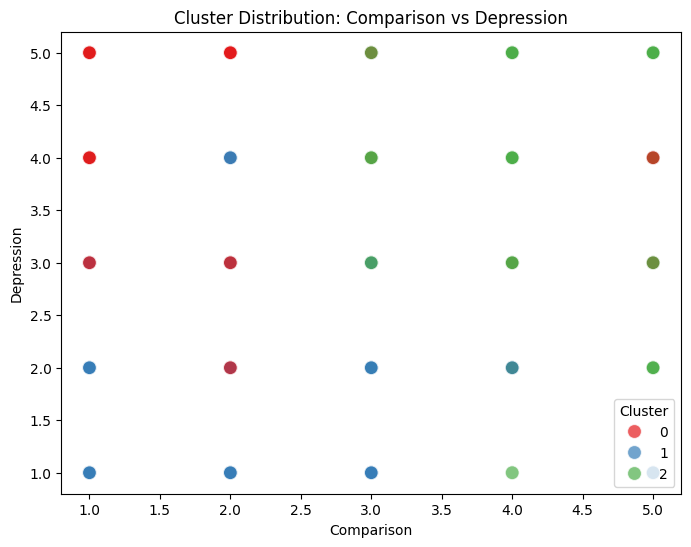

In [9]:
# 변수들의 스케일을 맞추기 위해 표준화 수행
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clean[X_cols + ['Depression']])

# K=3으로 군집화 모델 생성 및 학습
kmeans = KMeans(n_clusters=3, random_state=42)
df_clean['Cluster'] = kmeans.fit_predict(df_scaled)

# 군집별 특성 평균 계산하여 CSV 저장 (이 파일은 첨부됨)
cluster_summary = df_clean.groupby('Cluster')[X_cols + ['Depression', 'SM_Time_Num']].mean()
cluster_summary.to_csv('cluster_summary.csv')

# 타인과의 비교(Comparison)와 우울감(Depression)을 기준으로 한 군집 산점도 시각화
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Comparison', y='Depression', hue='Cluster', data=df_clean, palette='Set1', s=100, alpha=0.7)
plt.title('Cluster Distribution: Comparison vs Depression')
plt.show()

##4. 결론 도출하기
- 단순한 사용 시간보다 사용 방식이 중요
  - 다변량 분석 결과, 소셜 미디어를 오래 하더라도 단순히 콘텐츠를 소비하는 사용자(Cluster 0)보다 **타인의 성공과 자신을 비교하고 좋아요 등을 통해 검증을 받으려는 사용자(Cluster 2)가 훨씬 더 심각한 집중력 저하와 우울감을 겪음.**
- 악순환
  - **목적 없는 습관적 사용 $\rightarrow$ 타인과의 비교 노출 증가 $\rightarrow$ 걱정과 수면 장애 유발 $\rightarrow$ 높은 우울감**
  - 건강한 정신을 유지하기 위해서는 소셜 미디어 사용 시 뚜렷한 목적성을 가지고 접근해야 함. 타인과의 비교를 줄여야 함.